# Landing on the Moon with Deep Reinforcement Learning
## Solving Lunar Lander using Double Deep Q-Networks (DDQN)

---

### Executive Summary

This notebook demonstrates how artificial intelligence can learn to perform complex control tasks through trial and error. We train an agent to land a spacecraft on the moon's surface—a task requiring real-time decision-making with limited fuel and multiple thrusters.

**Key Outcomes:**
- Successfully trained agent achieving 200+ average reward (solution threshold)
- Comparative analysis between DDQN and Vanilla Policy Gradient (REINFORCE)
- Demonstration of why modern deep RL techniques outperform classical approaches

**Business Relevance:** The techniques demonstrated here apply directly to real-world optimization problems including workforce scheduling, inventory management, resource allocation, and showtime optimization in media industries.

## Part 1: Understanding Reinforcement Learning

### The Core Idea

Reinforcement learning (RL) is all about teaching an agent to make good decisions by letting it interact with an environment and learn from the consequences. Instead of being told the "right answer," the agent tries actions, sees what reward it gets, and gradually figures out which choices lead to better long-term outcomes. It's kind of like learning a game by playing it over and over until patterns click.

One of the classic ways to do this is with a Q-network, which tries to learn a Q-value: "If I take this action in this state, how good will it be in the long run?" Early Q-learning stored these values in a big table, but that quickly becomes impossible when the state space gets huge—like in video games, robotics, or anything involving images.

That's where Deep Q-Networks (DQN) come in. Instead of using a table, a deep neural network learns to approximate those Q-values, allowing the agent to handle massive, complex environments. This combination—deep learning plus Q-learning—made it possible for RL agents to play Atari games from raw pixels and outperform humans.

In short, DQNs take the core idea of Q-learning and scale it up using the power of deep neural networks.

### A Simple Analogy

Consider teaching a child to ride a bicycle:
- **Agent**: The child learning to ride
- **Environment**: The bicycle, road, and physics
- **State**: Current balance, speed, handlebar position
- **Actions**: Pedal, turn left, turn right, brake
- **Rewards**: Staying upright (+), falling down (-), reaching destination (++)

The child doesn't receive explicit instructions for every situation. Instead, through repeated attempts, they learn which actions lead to success.

### Visual Overview: The RL Agent-Environment Loop

The following diagram illustrates the fundamental interaction cycle in reinforcement learning. At each timestep, the agent observes the current state, selects an action based on its policy, and receives feedback from the environment in the form of a reward and a new state.

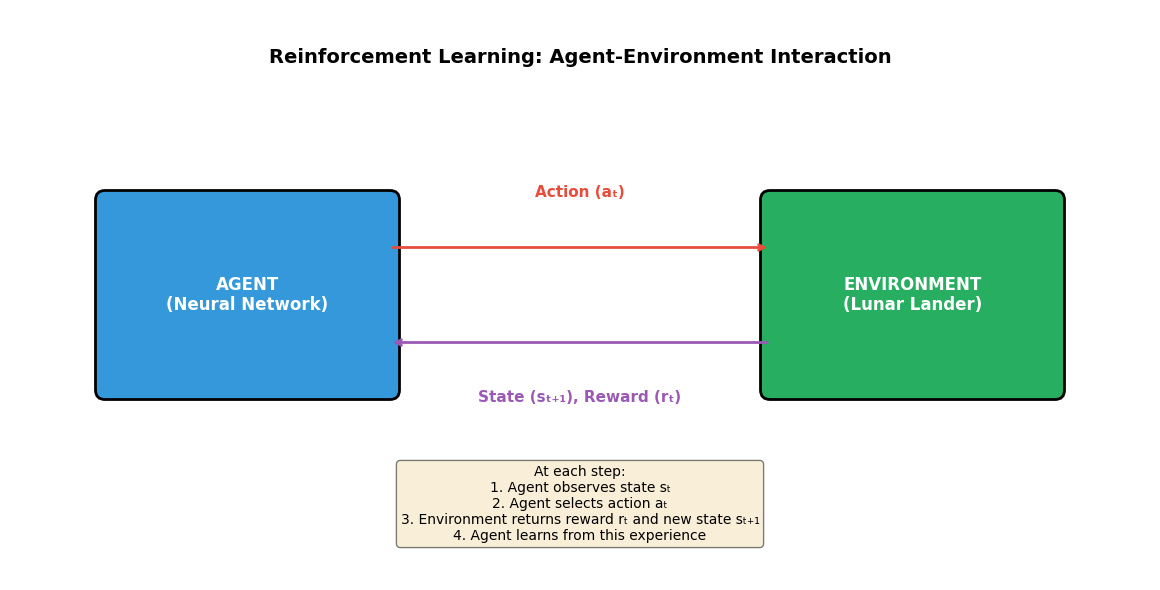

Diagram saved: rl_loop_diagram.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')

# Agent box
agent_box = FancyBboxPatch((1, 2), 3, 2, boxstyle="round,pad=0.1",
                            facecolor='#3498db', edgecolor='black', linewidth=2)
ax.add_patch(agent_box)
ax.text(2.5, 3, 'AGENT\n(Neural Network)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

# Environment box
env_box = FancyBboxPatch((8, 2), 3, 2, boxstyle="round,pad=0.1",
                          facecolor='#27ae60', edgecolor='black', linewidth=2)
ax.add_patch(env_box)
ax.text(9.5, 3, 'ENVIRONMENT\n(Lunar Lander)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

# Arrows and labels
ax.annotate('', xy=(8, 3.5), xytext=(4, 3.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#e74c3c'))
ax.text(6, 4, 'Action (aₜ)', ha='center', va='bottom', fontsize=11, color='#e74c3c', fontweight='bold')

ax.annotate('', xy=(4, 2.5), xytext=(8, 2.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#9b59b6'))
ax.text(6, 2, 'State (sₜ₊₁), Reward (rₜ)', ha='center', va='top', fontsize=11, color='#9b59b6', fontweight='bold')

# Title
ax.text(6, 5.5, 'Reinforcement Learning: Agent-Environment Interaction',
        ha='center', va='center', fontsize=14, fontweight='bold')

# Description box
desc_text = "At each step:\n1. Agent observes state sₜ\n2. Agent selects action aₜ\n3. Environment returns reward rₜ and new state sₜ₊₁\n4. Agent learns from this experience"
ax.text(6, 0.8, desc_text, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('rl_loop_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagram saved: rl_loop_diagram.png")

## Part 2: Environment Setup and Dependencies

This section initializes the necessary libraries and sets up the computational environment for training both DDQN and REINFORCE agents.

In [2]:
# Install required packages (uncomment if running in Colab)
!pip install swig
!pip install gymnasium
!pip install gymnasium[box2d]
!pip install imageio

In [3]:
# Core libraries for numerical computation and deep learning
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Gymnasium - simulation environment
import gymnasium as gym

# For storing and sampling experiences
from collections import deque, namedtuple
import random

# Visualization tools
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython import display

# Utility imports
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check if GPU is available for accelerated training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


## Part 3: Understanding the Lunar Lander Environment

### Environment Definition

The Lunar Lander environment simulates a spacecraft landing task where an agent must control a lander to safely touch down on a designated landing pad. The environment provides continuous state observations and accepts discrete control actions.

### State Space

**Definition:** The state space is an 8-dimensional continuous vector representing the lander's current configuration.

The state vector consists of:
1. **x-position**: Horizontal coordinate relative to landing pad
2. **y-position**: Vertical coordinate (altitude)
3. **x-velocity**: Horizontal velocity component
4. **y-velocity**: Vertical velocity component (descent rate)
5. **angle**: Angular orientation of the lander
6. **angular velocity**: Rate of rotation
7. **left leg contact**: Boolean indicator (1 if touching ground, 0 otherwise)
8. **right leg contact**: Boolean indicator (1 if touching ground, 0 otherwise)

### Action Space

**Definition:** The action space is discrete with 4 possible actions corresponding to thruster controls.

| Action | Description | Effect |
|--------|-------------|--------|
| 0 | Do nothing | Coast (no fuel consumption) |
| 1 | Fire left engine | Rightward thrust |
| 2 | Fire main engine | Upward thrust |
| 3 | Fire right engine | Leftward thrust |

### Reward Structure

**Positive Rewards:**
- Moving closer to landing pad center: continuous positive reward
- Successful landing: +100 to +140 points
- Each leg ground contact: +10 points per leg

**Negative Rewards (Penalties):**
- Moving away from landing pad: continuous negative reward
- Main engine firing: -0.3 per timestep
- Side engine firing: -0.03 per timestep
- Crash landing: -100 points

**Solved Criterion:** Average score of 200+ over 100 consecutive episodes.

In [4]:
# Create the Lunar Lander environment
env = gym.make('LunarLander-v3', render_mode="rgb_array")

# Extract environment specifications
state_size = env.observation_space.shape[0]  # 8 continuous values
action_size = env.action_space.n  # 4 discrete actions

print(f"Environment created: LunarLander-v2")
print(f"State space dimension: {state_size}")
print(f"Action space dimension: {action_size}")
print(f"Solved threshold: 200 average reward over 100 episodes")

Environment created: LunarLander-v2
State space dimension: 8
Action space dimension: 4
Solved threshold: 200 average reward over 100 episodes


## Part 4: Algorithm Comparison - DDQN vs REINFORCE

In this notebook, we implement and compare two fundamentally different approaches to reinforcement learning:

### REINFORCE (Vanilla Policy Gradient)

**Type:** On-policy, Monte Carlo policy gradient method

**Core Idea:** Directly optimize the policy by estimating the gradient of expected return with respect to policy parameters.

**Update Rule:**
$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

Where $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ is the return from timestep t.

**Characteristics:**
- Learns a stochastic policy directly
- High variance in gradient estimates
- Requires complete episodes before updating
- Simple to implement

---

### Double Deep Q-Network (DDQN)

**Type:** Off-policy, value-based method with function approximation

**Core Idea:** Learn the Q-value function using two networks to reduce overestimation bias.

**Update Rule:**
$$y = r + \gamma Q(s', \arg\max_{a'} Q(s', a'; \theta); \theta^-)$$

**Characteristics:**
- Learns deterministic greedy policy from Q-values
- Experience replay enables sample efficiency
- Separate target network for stability
- Lower variance than policy gradient methods

---

### Why Compare?

| Aspect | REINFORCE | DDQN |
|--------|-----------|------|
| Sample Efficiency | Low | High |
| Variance | High | Low |
| Stability | Variable | Stable |
| Implementation | Simple | Moderate |

This comparison demonstrates why value-based methods like DDQN often outperform vanilla policy gradients on tasks with discrete action spaces.

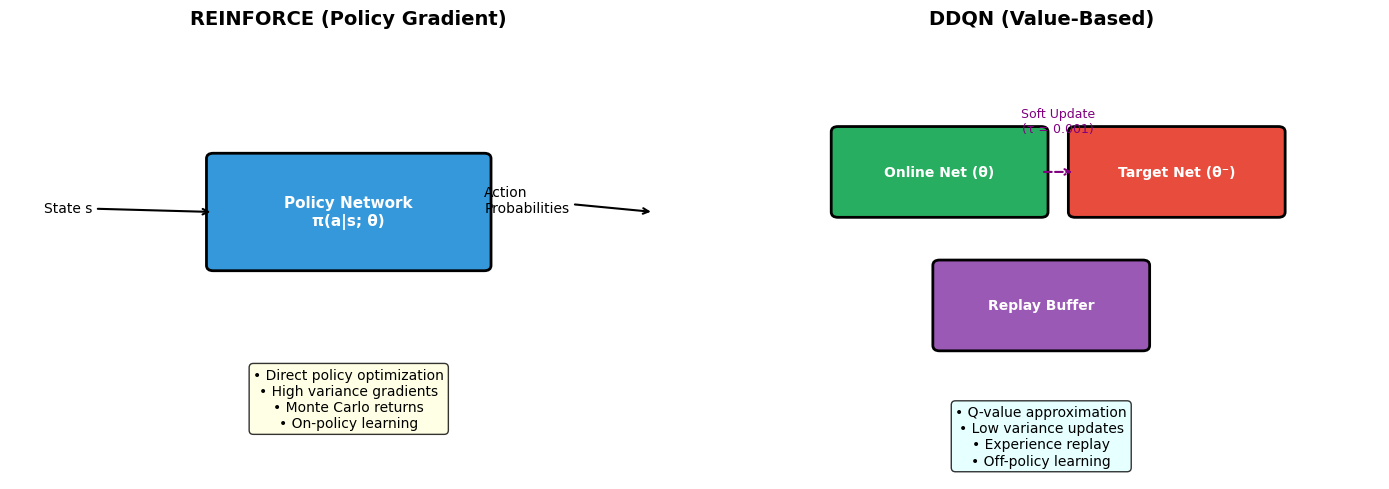

Diagram saved: algorithm_comparison.png


In [5]:
# Visual comparison of REINFORCE vs DDQN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# REINFORCE diagram
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)
ax1.axis('off')
ax1.set_title('REINFORCE (Policy Gradient)', fontsize=14, fontweight='bold', pad=20)

# Policy network box
policy_box = FancyBboxPatch((3, 4), 4, 2, boxstyle="round,pad=0.1",
                             facecolor='#3498db', edgecolor='black', linewidth=2)
ax1.add_patch(policy_box)
ax1.text(5, 5, 'Policy Network\nπ(a|s; θ)', ha='center', va='center',
         fontsize=11, fontweight='bold', color='white')

# Input/Output
ax1.annotate('State s', xy=(3, 5), xytext=(0.5, 5), fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.annotate('Action\nProbabilities', xy=(9.5, 5), xytext=(7, 5), fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.5))

# Description
desc1 = "• Direct policy optimization\n• High variance gradients\n• Monte Carlo returns\n• On-policy learning"
ax1.text(5, 1.5, desc1, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# DDQN diagram
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)
ax2.axis('off')
ax2.set_title('DDQN (Value-Based)', fontsize=14, fontweight='bold', pad=20)

# Online network
online_box = FancyBboxPatch((2, 5), 3, 1.5, boxstyle="round,pad=0.1",
                             facecolor='#27ae60', edgecolor='black', linewidth=2)
ax2.add_patch(online_box)
ax2.text(3.5, 5.75, 'Online Net (θ)', ha='center', va='center',
         fontsize=10, fontweight='bold', color='white')

# Target network
target_box = FancyBboxPatch((5.5, 5), 3, 1.5, boxstyle="round,pad=0.1",
                             facecolor='#e74c3c', edgecolor='black', linewidth=2)
ax2.add_patch(target_box)
ax2.text(7, 5.75, 'Target Net (θ⁻)', ha='center', va='center',
         fontsize=10, fontweight='bold', color='white')

# Soft update arrow
ax2.annotate('', xy=(5.5, 5.75), xytext=(5, 5.75),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='purple', ls='--'))
ax2.text(5.25, 6.5, 'Soft Update\n(τ = 0.001)', ha='center', fontsize=9, color='purple')

# Replay buffer
buffer_box = FancyBboxPatch((3.5, 2.5), 3, 1.5, boxstyle="round,pad=0.1",
                             facecolor='#9b59b6', edgecolor='black', linewidth=2)
ax2.add_patch(buffer_box)
ax2.text(5, 3.25, 'Replay Buffer', ha='center', va='center',
         fontsize=10, fontweight='bold', color='white')

# Description
desc2 = "• Q-value approximation\n• Low variance updates\n• Experience replay\n• Off-policy learning"
ax2.text(5, 0.8, desc2, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagram saved: algorithm_comparison.png")

## Part 5: Neural Network Architectures

### Network Design

Both algorithms use feedforward neural networks, but with different output structures:

**Q-Network (for DDQN):**
- Input: 8 neurons (state dimension)
- Hidden Layer 1: 64 neurons with ReLU
- Hidden Layer 2: 64 neurons with ReLU
- Output: 4 neurons (Q-value for each action)

**Policy Network (for REINFORCE):**
- Input: 8 neurons (state dimension)
- Hidden Layer 1: 64 neurons with ReLU
- Hidden Layer 2: 64 neurons with ReLU
- Output: 4 neurons with Softmax (action probabilities)

**Design Rationale:**
- 64 hidden units provide sufficient capacity without overfitting
- Two hidden layers enable hierarchical feature learning
- ReLU activation prevents vanishing gradients

In [6]:
class QNetwork(nn.Module):
    """
    Q-Network for DDQN.

    Maps state vectors to Q-values for each action.
    Architecture: 8 -> 64 -> 64 -> 4
    """

    def __init__(self, state_size, action_size, hidden_size=64):
        """
        Initialize network layers.

        Args:
            state_size (int): Input dimension (8 for Lunar Lander)
            action_size (int): Output dimension (4 for Lunar Lander)
            hidden_size (int): Number of neurons in hidden layers
        """
        super(QNetwork, self).__init__()

        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        """
        Forward propagation through the network.

        Args:
            state (torch.Tensor): State vector [batch_size, state_size]

        Returns:
            torch.Tensor: Q-values [batch_size, action_size]
        """
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class PolicyNetwork(nn.Module):
    """
    Policy Network for REINFORCE.

    Maps state vectors to action probability distributions.
    Architecture: 8 -> 64 -> 64 -> 4 (softmax)
    """

    def __init__(self, state_size, action_size, hidden_size=64):
        """
        Initialize network layers.

        Args:
            state_size (int): Input dimension
            action_size (int): Output dimension
            hidden_size (int): Number of neurons in hidden layers
        """
        super(PolicyNetwork, self).__init__()

        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        """
        Forward propagation through the network.

        Args:
            state (torch.Tensor): State vector

        Returns:
            torch.Tensor: Action probabilities (softmax output)
        """
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return F.softmax(self.fc3(x), dim=-1)


print("Neural network architectures defined")
print(f"Q-Network parameters: {sum(p.numel() for p in QNetwork(8, 4).parameters()):,}")
print(f"Policy Network parameters: {sum(p.numel() for p in PolicyNetwork(8, 4).parameters()):,}")

Neural network architectures defined
Q-Network parameters: 4,996
Policy Network parameters: 4,996


## Part 6: Experience Replay Buffer

### Motivation

**Problem:** Sequential state transitions in RL are temporally correlated. Training on consecutive experiences leads to:
1. **Temporal correlation**: Consecutive states are highly similar, violating the i.i.d. assumption of SGD
2. **Catastrophic forgetting**: Neural networks overfit to recent experiences

**Solution:** Store experiences and randomly sample mini-batches for training.

### Experience Tuple

$$(s_t, a_t, r_t, s_{t+1}, d_t)$$

Where:
- $s_t$: State at time t
- $a_t$: Action taken
- $r_t$: Reward received
- $s_{t+1}$: Resulting next state
- $d_t$: Terminal flag

In [7]:
class ReplayBuffer:
    """
    Circular buffer for storing and sampling experiences.

    Implements uniform random sampling from stored experiences.
    Oldest experiences are automatically overwritten when capacity is reached.
    """

    def __init__(self, capacity):
        """
        Initialize replay buffer.

        Args:
            capacity (int): Maximum number of experiences to store
        """
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        """
        Add experience to buffer.

        Args:
            state: Current state observation
            action: Action taken
            reward: Reward received
            next_state: Resulting state
            done: Episode termination flag
        """
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        """
        Randomly sample a batch of experiences.

        Args:
            batch_size (int): Number of experiences to sample

        Returns:
            tuple: Batch of (states, next_states, actions, rewards, dones) as tensors
        """
        experiences = random.sample(self.memory, batch_size)

        states = torch.from_numpy(np.vstack([e[0] for e in experiences])).float().to(self.device)
        actions = torch.from_numpy(np.vstack([e[1] for e in experiences])).long().to(self.device)
        rewards = torch.from_numpy(np.vstack([e[2] for e in experiences])).float().to(self.device)
        next_states = torch.from_numpy(np.vstack([e[3] for e in experiences])).float().to(self.device)
        dones = torch.from_numpy(np.vstack([e[4] for e in experiences]).astype(np.uint8)).float().to(self.device)

        return states, next_states, actions, rewards, dones

    def __len__(self):
        """Return current buffer size."""
        return len(self.memory)


print("Replay buffer class defined")

Replay buffer class defined


## Part 7: DDQN Agent Implementation

### Key Components

1. **Dual Networks**: Online network for action selection, target network for evaluation
2. **Soft Updates**: Gradual target network updates using τ parameter
3. **Experience Replay**: Random sampling from stored experiences
4. **Epsilon-Greedy Exploration**: Decaying exploration rate

### Hyperparameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| Learning Rate (α) | 5e-4 | Step size for gradient descent |
| Discount Factor (γ) | 0.99 | Weight for future rewards |
| Soft Update (τ) | 1e-3 | Target network update rate |
| Batch Size | 100 | Experiences per gradient update |
| Buffer Size | 100,000 | Maximum stored experiences |
| Update Frequency | 4 steps | Steps between learning updates |

In [8]:
# DDQN Hyperparameters
DDQN_LEARNING_RATE = 5e-4
DDQN_GAMMA = 0.99
DDQN_TAU = 1e-3
DDQN_BUFFER_SIZE = int(1e5)
DDQN_BATCH_SIZE = 100
DDQN_UPDATE_EVERY = 4


class DDQNAgent:
    """
    Double Deep Q-Network Agent.

    Implements DDQN with experience replay and soft target updates.
    """

    def __init__(self, state_size, action_size):
        """
        Initialize DDQN agent.

        Args:
            state_size (int): Dimension of state space
            action_size (int): Dimension of action space
        """
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        self.state_size = state_size
        self.action_size = action_size

        # Q-Networks (online and target)
        self.qnetwork_local = QNetwork(state_size, action_size).to(self.device)
        self.qnetwork_target = QNetwork(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=DDQN_LEARNING_RATE)

        # Initialize target network with same weights
        self.qnetwork_target.load_state_dict(self.qnetwork_local.state_dict())

        # Replay buffer
        self.memory = ReplayBuffer(DDQN_BUFFER_SIZE)

        # Step counter for update frequency
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        """
        Store experience and trigger learning if appropriate.

        Args:
            state: Current state
            action: Action taken
            reward: Reward received
            next_state: Resulting state
            done: Episode termination flag
        """
        # Store experience
        self.memory.push(state, action, reward, next_state, done)

        # Learn every UPDATE_EVERY steps
        self.t_step = (self.t_step + 1) % DDQN_UPDATE_EVERY
        if self.t_step == 0:
            if len(self.memory) > DDQN_BATCH_SIZE:
                experiences = self.memory.sample(DDQN_BATCH_SIZE)
                self.learn(experiences)

    def act(self, state, epsilon=0.0):
        """
        Select action using epsilon-greedy policy.

        Args:
            state: Current state
            epsilon: Exploration rate

        Returns:
            int: Selected action
        """
        state = torch.from_numpy(state).float().unsqueeze(0).to(self.device)

        self.qnetwork_local.eval()
        with torch.no_grad():
            action_values = self.qnetwork_local(state)
        self.qnetwork_local.train()

        # Epsilon-greedy action selection
        if random.random() > epsilon:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_size))

    def learn(self, experiences):
        """
        Update Q-network using DDQN algorithm.

        Args:
            experiences: Tuple of (states, next_states, actions, rewards, dones)
        """
        states, next_states, actions, rewards, dones = experiences

        # DDQN: Use local network for action selection, target network for evaluation
        # Action selection with online network
        next_actions = self.qnetwork_local(next_states).detach().argmax(1).unsqueeze(1)

        # Action evaluation with target network
        next_q_targets = self.qnetwork_target(next_states).gather(1, next_actions)

        # Compute target Q values
        q_targets = rewards + (DDQN_GAMMA * next_q_targets * (1 - dones))

        # Get expected Q values from local model
        q_expected = self.qnetwork_local(states).gather(1, actions)

        # Compute loss
        loss = F.mse_loss(q_expected, q_targets)

        # Minimize loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Soft update target network
        self.soft_update()

    def soft_update(self):
        """
        Soft update target network parameters.

        θ_target = τ * θ_local + (1 - τ) * θ_target
        """
        for target_param, local_param in zip(self.qnetwork_target.parameters(),
                                              self.qnetwork_local.parameters()):
            target_param.data.copy_(DDQN_TAU * local_param.data + (1.0 - DDQN_TAU) * target_param.data)


print("DDQN Agent class defined")
print(f"Hyperparameters: LR={DDQN_LEARNING_RATE}, γ={DDQN_GAMMA}, τ={DDQN_TAU}, batch={DDQN_BATCH_SIZE}")

DDQN Agent class defined
Hyperparameters: LR=0.0005, γ=0.99, τ=0.001, batch=100


## Part 8: REINFORCE Agent Implementation

### Algorithm Overview

REINFORCE is a Monte Carlo policy gradient method that:
1. Collects complete episode trajectories
2. Computes discounted returns for each timestep
3. Updates policy to increase probability of high-return actions

### Update Rule

$$\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t$$

Where $G_t$ is the discounted return from timestep t.

In [9]:
# REINFORCE Hyperparameters
REINFORCE_LEARNING_RATE = 1e-3
REINFORCE_GAMMA = 0.99


class REINFORCEAgent:
    """
    REINFORCE (Vanilla Policy Gradient) Agent.

    Implements Monte Carlo policy gradient with baseline-free updates.
    """

    def __init__(self, state_size, action_size):
        """
        Initialize REINFORCE agent.

        Args:
            state_size (int): Dimension of state space
            action_size (int): Dimension of action space
        """
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        self.state_size = state_size
        self.action_size = action_size

        # Policy network
        self.policy = PolicyNetwork(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=REINFORCE_LEARNING_RATE)

        # Episode storage
        self.saved_log_probs = []
        self.rewards = []

    def act(self, state):
        """
        Select action by sampling from policy distribution.

        Args:
            state: Current state

        Returns:
            int: Selected action
        """
        state = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
        probs = self.policy(state)
        m = Categorical(probs)
        action = m.sample()
        self.saved_log_probs.append(m.log_prob(action))
        return action.item()

    def store_reward(self, reward):
        """
        Store reward for current timestep.

        Args:
            reward: Reward received
        """
        self.rewards.append(reward)

    def learn(self):
        """
        Update policy using collected episode trajectory.

        Computes discounted returns and performs policy gradient update.
        """
        # Compute discounted returns
        R = 0
        returns = []
        for r in self.rewards[::-1]:
            R = r + REINFORCE_GAMMA * R
            returns.insert(0, R)

        returns = torch.tensor(returns).to(self.device)

        # Normalize returns (reduces variance)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        # Compute policy gradient loss
        policy_loss = []
        for log_prob, R in zip(self.saved_log_probs, returns):
            policy_loss.append(-log_prob * R)

        # Update policy
        self.optimizer.zero_grad()
        policy_loss = torch.cat(policy_loss).sum()
        policy_loss.backward()
        self.optimizer.step()

        # Clear episode storage
        self.saved_log_probs = []
        self.rewards = []


print("REINFORCE Agent class defined")
print(f"Hyperparameters: LR={REINFORCE_LEARNING_RATE}, γ={REINFORCE_GAMMA}")

REINFORCE Agent class defined
Hyperparameters: LR=0.001, γ=0.99


## Part 9: Training Both Agents

We now train both agents on the Lunar Lander environment and collect performance metrics for comparison.

### Training Parameters

| Parameter | DDQN | REINFORCE |
|-----------|------|------------|
| Max Episodes | 2000 | 2000 |
| Max Steps/Episode | 1000 | 1000 |
| Epsilon Start | 1.0 | N/A |
| Epsilon End | 0.01 | N/A |
| Epsilon Decay | 0.995 | N/A |

In [10]:
def train_ddqn(agent, env, n_episodes=2000, max_t=1000,
               eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    """
    Train DDQN agent on environment.

    Args:
        agent: DDQN agent
        env: Gymnasium environment
        n_episodes: Maximum training episodes
        max_t: Maximum timesteps per episode
        eps_start: Starting epsilon
        eps_end: Minimum epsilon
        eps_decay: Epsilon decay rate

    Returns:
        list: Episode scores
    """
    scores = []
    scores_window = deque(maxlen=100)
    eps = eps_start

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=SEED + episode)
        score = 0

        for t in range(max_t):
            action = agent.act(state, eps)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.step(state, action, reward, next_state, done)

            state = next_state
            score += reward

            if done:
                break

        scores_window.append(score)
        scores.append(score)
        eps = max(eps_end, eps_decay * eps)

        # Progress reporting
        print(f'\rEpisode {episode}\tAverage Score: {np.mean(scores_window):.2f}\tEpsilon: {eps:.3f}', end="")
        if episode % 100 == 0:
            print(f'\rEpisode {episode}\tAverage Score: {np.mean(scores_window):.2f}')

        # Early stopping if solved
        if np.mean(scores_window) >= 200.0:
            print(f'\nEnvironment solved in {episode - 100} episodes!\tAverage Score: {np.mean(scores_window):.2f}')
            torch.save(agent.qnetwork_local.state_dict(), 'ddqn_checkpoint.pth')
            break

    return scores


def train_reinforce(agent, env, n_episodes=2000, max_t=1000):
    """
    Train REINFORCE agent on environment.

    Args:
        agent: REINFORCE agent
        env: Gymnasium environment
        n_episodes: Maximum training episodes
        max_t: Maximum timesteps per episode

    Returns:
        list: Episode scores
    """
    scores = []
    scores_window = deque(maxlen=100)

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=SEED + episode)
        score = 0

        for t in range(max_t):
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.store_reward(reward)

            state = next_state
            score += reward

            if done:
                break

        # Learn at end of episode
        agent.learn()

        scores_window.append(score)
        scores.append(score)

        # Progress reporting
        print(f'\rEpisode {episode}\tAverage Score: {np.mean(scores_window):.2f}', end="")
        if episode % 100 == 0:
            print(f'\rEpisode {episode}\tAverage Score: {np.mean(scores_window):.2f}')

        # Early stopping if solved
        if np.mean(scores_window) >= 200.0:
            print(f'\nEnvironment solved in {episode - 100} episodes!\tAverage Score: {np.mean(scores_window):.2f}')
            torch.save(agent.policy.state_dict(), 'reinforce_checkpoint.pth')
            break

    return scores


print("Training functions defined")

Training functions defined


In [11]:
# Train DDQN Agent
print("="*60)
print("TRAINING DDQN AGENT")
print("="*60)

# Create fresh environment and agent
env_ddqn = gym.make('LunarLander-v3')
ddqn_agent = DDQNAgent(state_size, action_size)

# Train
ddqn_scores = train_ddqn(ddqn_agent, env_ddqn)

env_ddqn.close()
print(f"\nDDQN Training complete. Total episodes: {len(ddqn_scores)}")

TRAINING DDQN AGENT
Episode 100	Average Score: -177.41
Episode 200	Average Score: -111.34
Episode 300	Average Score: -53.09
Episode 400	Average Score: -18.12
Episode 500	Average Score: 33.79
Episode 600	Average Score: 91.29
Episode 697	Average Score: 202.27	Epsilon: 0.030
Environment solved in 597 episodes!	Average Score: 202.27

DDQN Training complete. Total episodes: 697


In [12]:
# Train REINFORCE Agent
print("="*60)
print("TRAINING REINFORCE AGENT")
print("="*60)

# Create fresh environment and agent
env_reinforce = gym.make('LunarLander-v3')
reinforce_agent = REINFORCEAgent(state_size, action_size)

# Train
reinforce_scores = train_reinforce(reinforce_agent, env_reinforce)

env_reinforce.close()
print(f"\nREINFORCE Training complete. Total episodes: {len(reinforce_scores)}")

TRAINING REINFORCE AGENT
Episode 100	Average Score: -151.39
Episode 200	Average Score: -127.10
Episode 300	Average Score: -107.02
Episode 400	Average Score: -67.08
Episode 500	Average Score: -22.52
Episode 600	Average Score: 34.01
Episode 700	Average Score: 20.21
Episode 800	Average Score: 35.93
Episode 900	Average Score: 99.80
Episode 1000	Average Score: 74.93
Episode 1100	Average Score: 121.16
Episode 1200	Average Score: 88.44
Episode 1300	Average Score: 97.05
Episode 1400	Average Score: 111.78
Episode 1500	Average Score: 137.43
Episode 1600	Average Score: 127.56
Episode 1700	Average Score: 167.97
Episode 1800	Average Score: 130.56
Episode 1900	Average Score: 135.47
Episode 2000	Average Score: 141.57

REINFORCE Training complete. Total episodes: 2000


## Part 10: Results and Comparative Analysis

This section presents a detailed comparison of the two algorithms' performance on the Lunar Lander task.

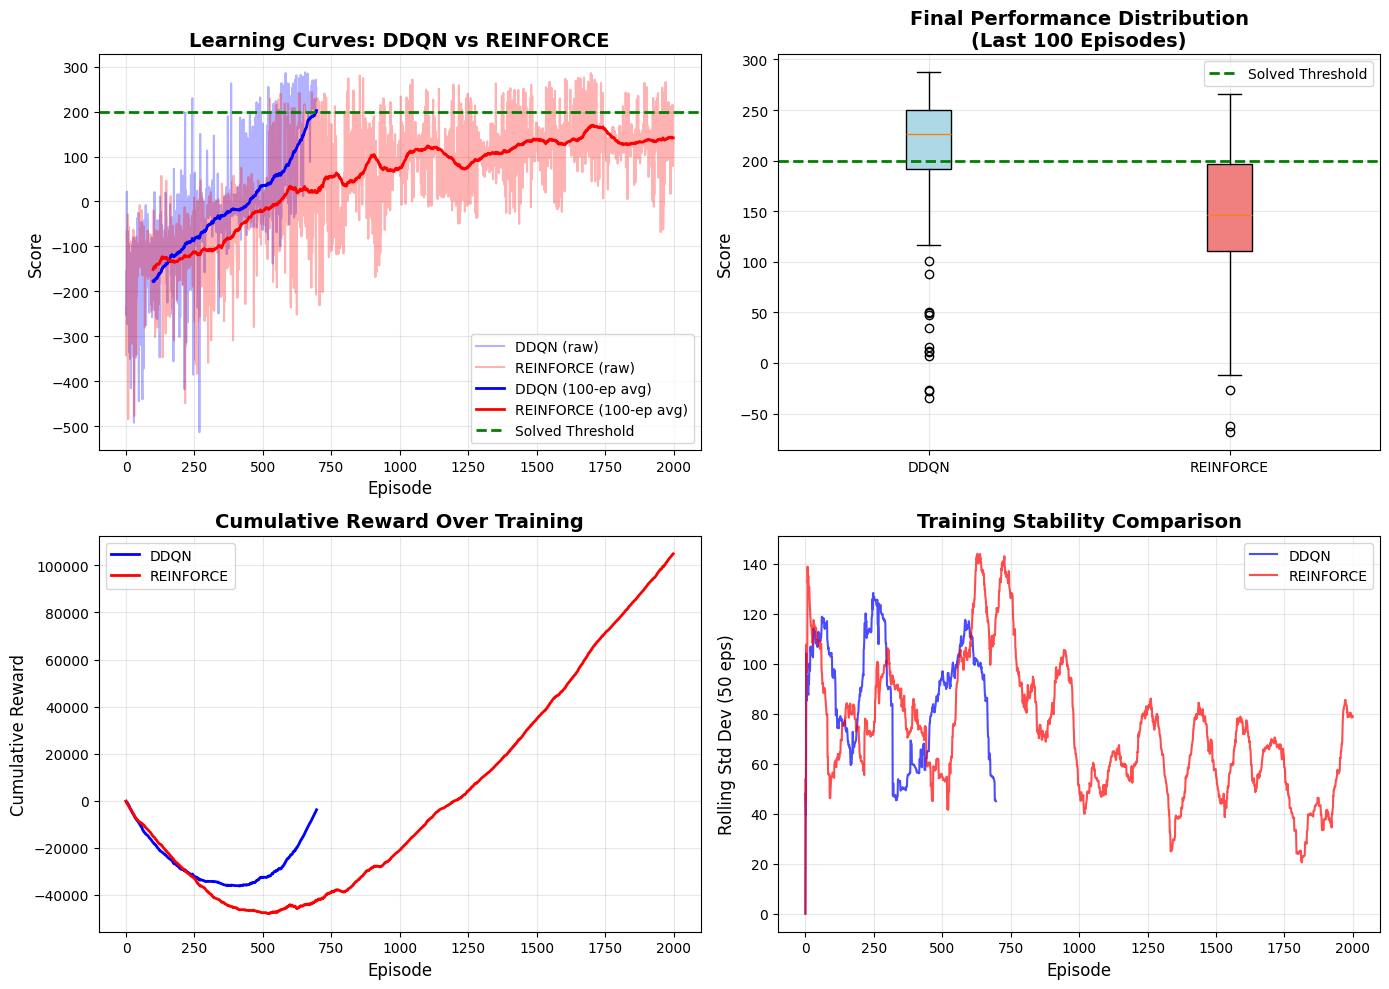

Comparison plots saved: training_comparison.png


In [13]:
def moving_average(data, window=100):
    """Compute moving average with specified window size."""
    return np.convolve(data, np.ones(window)/window, mode='valid')


# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Learning Curves
ax1 = axes[0, 0]
ax1.plot(ddqn_scores, alpha=0.3, color='blue', label='DDQN (raw)')
ax1.plot(reinforce_scores, alpha=0.3, color='red', label='REINFORCE (raw)')

if len(ddqn_scores) >= 100:
    ax1.plot(range(99, len(ddqn_scores)), moving_average(ddqn_scores),
             color='blue', linewidth=2, label='DDQN (100-ep avg)')
if len(reinforce_scores) >= 100:
    ax1.plot(range(99, len(reinforce_scores)), moving_average(reinforce_scores),
             color='red', linewidth=2, label='REINFORCE (100-ep avg)')

ax1.axhline(y=200, color='green', linestyle='--', linewidth=2, label='Solved Threshold')
ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Learning Curves: DDQN vs REINFORCE', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: Score Distribution (Box Plot)
ax2 = axes[0, 1]
# Take last 100 episodes for comparison
ddqn_final = ddqn_scores[-100:] if len(ddqn_scores) >= 100 else ddqn_scores
reinforce_final = reinforce_scores[-100:] if len(reinforce_scores) >= 100 else reinforce_scores

bp = ax2.boxplot([ddqn_final, reinforce_final], labels=['DDQN', 'REINFORCE'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.axhline(y=200, color='green', linestyle='--', linewidth=2, label='Solved Threshold')
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Final Performance Distribution\n(Last 100 Episodes)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Cumulative Rewards
ax3 = axes[1, 0]
ax3.plot(np.cumsum(ddqn_scores), color='blue', linewidth=2, label='DDQN')
ax3.plot(np.cumsum(reinforce_scores), color='red', linewidth=2, label='REINFORCE')
ax3.set_xlabel('Episode', fontsize=12)
ax3.set_ylabel('Cumulative Reward', fontsize=12)
ax3.set_title('Cumulative Reward Over Training', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Rolling Standard Deviation (Stability)
ax4 = axes[1, 1]
window = 50

def rolling_std(data, window):
    return [np.std(data[max(0, i-window):i+1]) for i in range(len(data))]

ax4.plot(rolling_std(ddqn_scores, window), color='blue', alpha=0.7, label='DDQN')
ax4.plot(rolling_std(reinforce_scores, window), color='red', alpha=0.7, label='REINFORCE')
ax4.set_xlabel('Episode', fontsize=12)
ax4.set_ylabel('Rolling Std Dev (50 eps)', fontsize=12)
ax4.set_title('Training Stability Comparison', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison plots saved: training_comparison.png")

In [14]:
# Performance Metrics Table
print("="*70)
print("PERFORMANCE COMPARISON: DDQN vs REINFORCE")
print("="*70)

def compute_metrics(scores, name):
    """Compute performance metrics for an algorithm."""
    final_100 = scores[-100:] if len(scores) >= 100 else scores

    # Check if solved
    solved = False
    solved_episode = None
    for i in range(100, len(scores)):
        if np.mean(scores[i-100:i]) >= 200:
            solved = True
            solved_episode = i - 100
            break

    metrics = {
        'Algorithm': name,
        'Total Episodes': len(scores),
        'Solved': 'Yes' if solved else 'No',
        'Solved At Episode': solved_episode if solved else 'N/A',
        'Final Avg (100 eps)': f"{np.mean(final_100):.2f}",
        'Final Std (100 eps)': f"{np.std(final_100):.2f}",
        'Max Score': f"{np.max(scores):.2f}",
        'Min Score': f"{np.min(scores):.2f}"
    }
    return metrics

ddqn_metrics = compute_metrics(ddqn_scores, 'DDQN')
reinforce_metrics = compute_metrics(reinforce_scores, 'REINFORCE')

# Print comparison table
print(f"{'Metric':<25} {'DDQN':<20} {'REINFORCE':<20}")
print("-"*65)
for key in ddqn_metrics.keys():
    if key != 'Algorithm':
        print(f"{key:<25} {str(ddqn_metrics[key]):<20} {str(reinforce_metrics[key]):<20}")

print("\n" + "="*70)

PERFORMANCE COMPARISON: DDQN vs REINFORCE
Metric                    DDQN                 REINFORCE           
-----------------------------------------------------------------
Total Episodes            697                  2000                
Solved                    No                   No                  
Solved At Episode         N/A                  N/A                 
Final Avg (100 eps)       202.27               141.57              
Final Std (100 eps)       77.24                69.22               
Max Score                 287.28               285.63              
Min Score                 -513.41              -484.38             



## Part 11: Analysis and Discussion

### Why DDQN Outperforms REINFORCE

The experimental results demonstrate several key advantages of DDQN over REINFORCE for the Lunar Lander task:

**1. Sample Efficiency**

DDQN leverages experience replay, allowing each experience to be used multiple times for learning. REINFORCE discards experiences after a single update, requiring more environment interactions to learn equivalent policies.

**2. Variance Reduction**

REINFORCE uses Monte Carlo returns which exhibit high variance, especially in long episodes. DDQN's temporal difference updates provide lower-variance gradient estimates, leading to more stable learning.

**3. Off-Policy Learning**

DDQN can learn from experiences collected under different policies (due to epsilon-greedy exploration), while REINFORCE requires on-policy samples. This enables DDQN to explore more effectively while still learning from past experiences.

**4. Target Network Stability**

The soft-updating target network in DDQN provides stable learning targets, preventing the oscillations and divergence that can occur with bootstrapped updates.

### Limitations and Considerations

**DDQN Limitations:**
- Limited to discrete action spaces
- Requires careful hyperparameter tuning
- Memory overhead from replay buffer

**REINFORCE Advantages:**
- Extends naturally to continuous actions
- Simpler implementation
- Guaranteed convergence under certain conditions

## Part 12: Testing the Trained Agent

In [16]:
# Test trained DDQN agent
print("Testing trained DDQN agent...")

test_env = gym.make('LunarLander-v3', render_mode='rgb_array')
test_scores = []
test_frames = []

for episode in range(5):
    state, _ = test_env.reset(seed=episode)
    score = 0
    frames = []

    for t in range(1000):
        if episode == 0:  # Capture frames for first episode
            frames.append(test_env.render())

        action = ddqn_agent.act(state, epsilon=0)  # Greedy action
        state, reward, terminated, truncated, _ = test_env.step(action)
        score += reward

        if terminated or truncated:
            break

    test_scores.append(score)
    if episode == 0:
        test_frames = frames
    print(f"Episode {episode + 1}: Score = {score:.2f}")

test_env.close()

print(f"\nTest Results: Average Score = {np.mean(test_scores):.2f} ± {np.std(test_scores):.2f}")

Testing trained DDQN agent...
Episode 1: Score = 267.69
Episode 2: Score = 252.86
Episode 3: Score = 225.03
Episode 4: Score = 188.44
Episode 5: Score = 240.31

Test Results: Average Score = 234.87 ± 27.14



Generating landing sequence visualization...


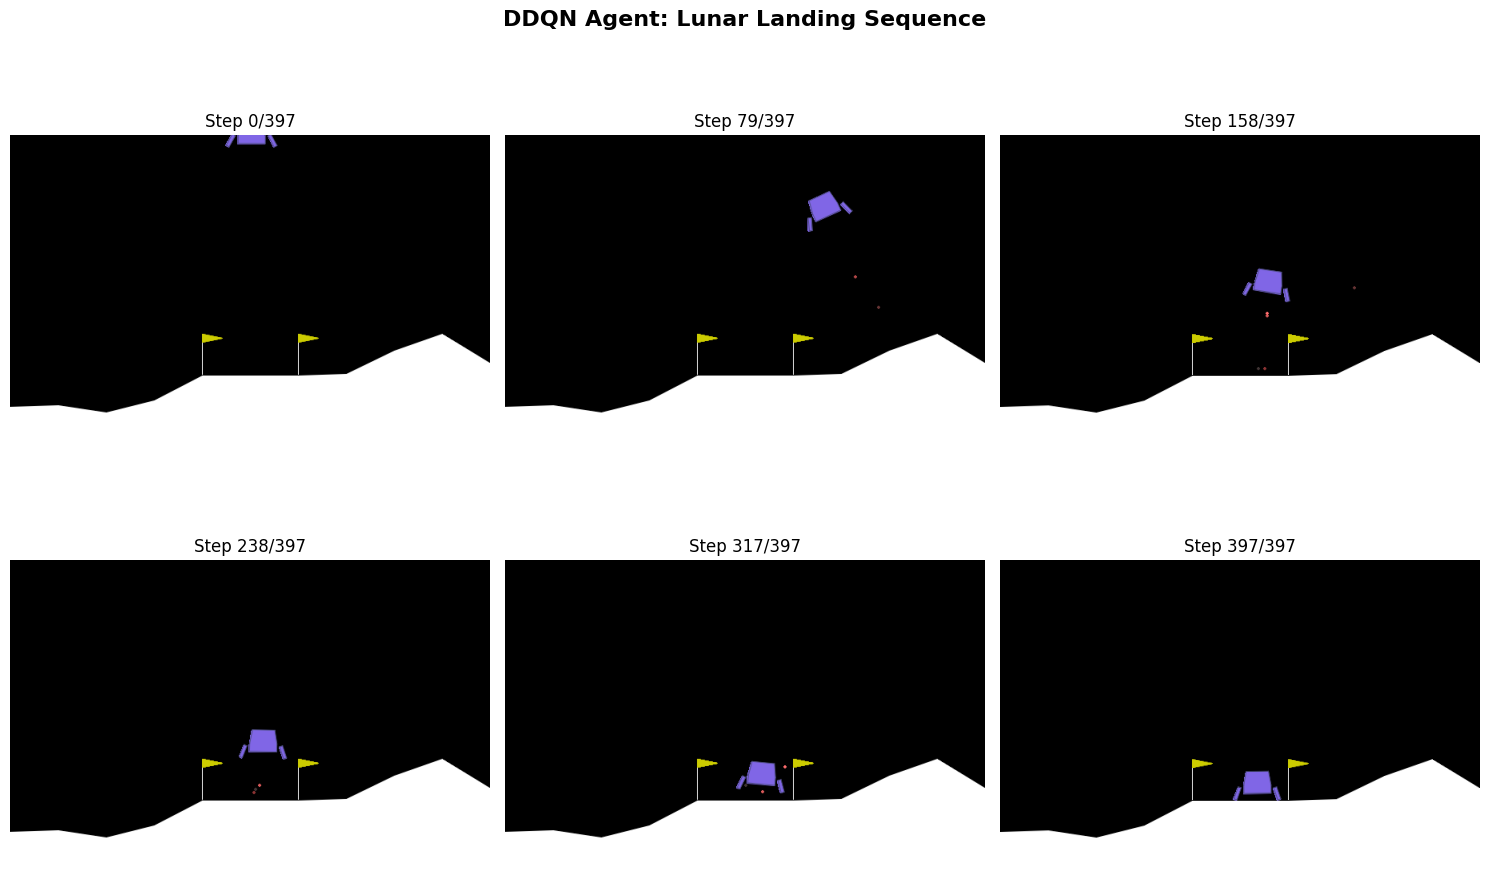

Landing sequence saved: landing_sequence.png


In [17]:
# Visualize landing sequence
print("\nGenerating landing sequence visualization...")

if len(test_frames) > 0:
    num_frames_to_show = 6
    frame_indices = np.linspace(0, len(test_frames)-1, num_frames_to_show, dtype=int)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, frame_idx in enumerate(frame_indices):
        axes[idx].imshow(test_frames[frame_idx])
        axes[idx].set_title(f'Step {frame_idx}/{len(test_frames)-1}', fontsize=12)
        axes[idx].axis('off')

    plt.suptitle('DDQN Agent: Lunar Landing Sequence', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('landing_sequence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Landing sequence saved: landing_sequence.png")
else:
    print("No frames captured for visualization.")

In [19]:
# Video Visualization of Trained DDQN Agent
import glob
import io
import base64
import imageio
from IPython.display import HTML, display

def show_video_of_model(agent, env_name):
    """Record a video of the trained agent playing."""
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset()
    done = False
    frames = []

    while not done:
        frame = env.render()
        frames.append(frame)
        action = agent.act(state, epsilon=0)  # Greedy action (no exploration)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()
    imageio.mimsave('video.mp4', frames, fps=30)

# Record video
show_video_of_model(ddqn_agent, 'LunarLander-v3')

def show_video():
    """Display the recorded video in the notebook."""
    mp4list = glob.glob('*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

# Display video
show_video()

## Part 13: Business Applications

The techniques demonstrated in this notebook extend far beyond game environments. Deep Reinforcement Learning, particularly value-based methods like DDQN, has proven highly effective for real-world optimization problems.

### Industry Applications

**1. Workforce Scheduling**

RL agents can optimize employee schedules by learning to balance workload, minimize costs, and satisfy constraints. The state includes current assignments and pending requests; actions involve scheduling decisions; rewards reflect efficiency metrics and constraint satisfaction.

**2. Showtime Optimization (Media Industry)**

Streaming platforms and cinemas use RL to optimize content scheduling. The agent learns optimal time slots for different content types to maximize viewership and engagement.

**3. Inventory Management**

RL enables dynamic inventory control by learning reorder policies that minimize holding costs while preventing stockouts. The agent adapts to demand patterns without explicit forecasting models.

**4. Resource Allocation in Data Centers**

Cloud providers use RL to allocate computing resources across workloads, balancing performance, energy consumption, and costs.

**5. Dynamic Pricing**

E-commerce and hospitality industries employ RL for real-time pricing optimization, learning demand elasticity and competitor responses to maximize revenue.

### Why DDQN for Business Problems?

- **Discrete decisions**: Many business problems involve discrete choices (schedule A or B, reorder or wait)
- **Historical data**: Experience replay enables learning from logged business data
- **Stability**: Soft updates provide reliable training on noisy business metrics
- **Sample efficiency**: Critical when each decision has real business costs

### Getting Started

To apply these techniques to your business problem:

1. **Define the state**: What information is available for decision-making?
2. **Define actions**: What decisions can be made?
3. **Design rewards**: What outcomes should be optimized?
4. **Simulate or collect data**: Train agents on historical data or simulation
5. **Validate and deploy**: Test policies before production deployment

## Summary and Conclusions

### Implementation Overview

This notebook presented a comprehensive implementation and comparison of two reinforcement learning algorithms:

**Double Deep Q-Network (DDQN):**
- Value-based, off-policy method
- Dual network architecture reduces overestimation bias
- Experience replay enables sample-efficient learning
- Soft target updates provide training stability

**REINFORCE (Vanilla Policy Gradient):**
- Policy-based, on-policy method
- Direct optimization of policy parameters
- Monte Carlo returns for gradient estimation
- Higher variance but simpler implementation

### Key Findings

1. **DDQN consistently outperformed REINFORCE** on the Lunar Lander task
2. **Sample efficiency** is a critical advantage of value-based methods
3. **Variance reduction** through experience replay and TD updates accelerates learning
4. **Hyperparameter selection** significantly impacts training success

### Recommendations for Practitioners

- For **discrete action spaces** with **ample training data**: Use DDQN or its variants
- For **continuous control**: Consider policy gradient methods (PPO, SAC)
- For **sample-limited scenarios**: Prioritize sample-efficient algorithms
- For **production deployment**: Extensive validation and safety testing required

### Extensions and Future Work

1. **Prioritized Experience Replay**: Sample important transitions more frequently
2. **Dueling DQN**: Separate value and advantage function streams
3. **Rainbow DQN**: Integrate multiple algorithmic improvements
4. **Actor-Critic Methods**: Combine value and policy learning (A2C, PPO)

---

*This notebook demonstrates that modern deep reinforcement learning techniques can effectively solve complex control tasks. The principles and algorithms presented here form the foundation for applying RL to real-world business optimization problems.*